In [5]:
import os
import csv
import glob
import struct
import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
from scipy import ndimage, signal, optimize

plt.rcParams['font.family'] = 'Arial'

PATH = os.getcwd()

CSV_PATH = r"E:\fus-thermal\In_vitro_20260904\water_tank_260904_115425\thermal_experiment_T02_glass1layer_2.095MHz_2026-09-04_11-54-20.csv"

# Column names in that CSV
X_KEY, Y_KEY, Z_KEY = 'x (mm)', 'y (mm)', 'z (mm)'
P_KEY = 'P (MPa)'

DISPLAY_FS = 120  # Hz, everything downstream of loading runs at this rate
OVERVIEW_FS = 4   # Hz, further decimation for the hours-long session overview

# Filter window for baseline estimate
BASELINE_WINDOW = 600.0  # s

# Triggered average properties
PRE = 0.5  # s, window length before each trigger burst onset
DURATION = 3.0  # s, window length after each trigger burst onset
BASELINE_PRE = 0.4  # s, pre-onset span averaged and subtracted from each trial

LOWPASS_FS = 30  # Hz, lowpass filter cutoff frequency for analog signal
GROUP_GAP = 1.0  # s, edges further apart than this start a new burst

# Double-exponential fit bounds
FIT_MIN_AMPLITUDE_C = 0.03  # degC
FIT_MAX_AMPLITUDE_C = 2.0  # degC

FIT_MAX_TAU_RISE = 1.0  # s

ID_PAGE_KEY = Z_KEY
GRID_ROW_KEY = Z_KEY
GRID_COL_KEY = X_KEY
GRID_PAGE_KEY = Y_KEY

# Osensa fiber-optic temperature probe consts from Misi. todo: check
OSENSA_TZERO_C = 0.0
OSENSA_TSPAN_C = 100.0
OSENSA_RA_OHM = 149.3
OSENSA_I_MIN_A = 4e-3
OSENSA_I_MAX_A = 20e-3
OSENSA_GAIN_C_PER_V = OSENSA_TSPAN_C / (OSENSA_RA_OHM * (OSENSA_I_MAX_A - OSENSA_I_MIN_A))

In [6]:
def intan_layout(folder):
    """Sample rate (Hz), sample count and analog channel count for a recording.

    The rate comes straight out of info.rhd's fixed-offset header: magic number
    (4B) + version major/minor (2x int16) + sample_rate (float32). The channel
    count is inferred from the analogin.dat / time.dat file-size ratio (uint16
    vs int32 samples).
    """
    with open(f'{folder}/info.rhd', 'rb') as f:
        magic_number, = struct.unpack('<I', f.read(4))
        if magic_number != 0xc6912702:
            raise ValueError(f'{folder}/info.rhd is not a valid Intan RHD header')
        f.read(4)  # version major/minor, unused here
        fs, = struct.unpack('<f', f.read(4))

    time_bytes = os.path.getsize(f'{folder}/time.dat')
    analog_bytes = os.path.getsize(f'{folder}/analogin.dat')
    return fs, time_bytes // 4, round(2 * analog_bytes / time_bytes)


def load_analog_downsampled(folder, display_fs=DISPLAY_FS, channel=0, adc_scale=50.354e-6):
    """Mean-downsample one analogin channel straight off disk, in chunks.

    display_fs is the rate every later step (drift, filtering, trial
    extraction) works at; averaging each bin doubles as a boxcar lowpass.

    Returns (t_ds, v_ds, fs, ds_fs): seconds, Volts, raw rate, downsampled rate.
    time.dat is checked for continuity rather than read in full (it is another
    1 GB); if it ever has gaps, this assumption needs revisiting.
    """
    fs, n_samples, n_channels = intan_layout(folder)

    t_raw = np.memmap(f'{folder}/time.dat', dtype=np.int32, mode='r')
    if int(t_raw[-1]) - int(t_raw[0]) + 1 != n_samples:
        raise ValueError(f'{folder}/time.dat is not contiguous; sample times need reading in full')

    analog = np.memmap(f'{folder}/analogin.dat', dtype=np.uint16, mode='r')
    bin_size = max(int(round(fs / display_fs)), 1)
    n_bins = n_samples // bin_size

    v_ds = np.empty(n_bins, dtype=np.float64)
    chunk_bins = 100_000
    for start_bin in range(0, n_bins, chunk_bins):
        stop_bin = min(start_bin + chunk_bins, n_bins)
        block = np.asarray(
            analog[(start_bin * bin_size) * n_channels:(stop_bin * bin_size) * n_channels],
            dtype=np.float64)
        block = block.reshape(-1, n_channels)[:, channel]
        v_ds[start_bin:stop_bin] = block.reshape(stop_bin - start_bin, bin_size).mean(axis=1)
    v_ds *= adc_scale

    return (np.arange(n_bins) + 0.5) * bin_size / fs, v_ds, fs, fs / bin_size


def load_digital_rising_edges(folder, line):
    """Sample indices of every rising edge on one digitalin line, found in
    chunks off a memory map. Only the requested bit is ever unpacked.
    """
    words = np.memmap(f'{folder}/digitalin.dat', dtype=np.uint16, mode='r')

    edges = []
    previous = np.int8(0)
    chunk = 20_000_000
    for start in range(0, words.size, chunk):
        bits = ((np.asarray(words[start:start + chunk]) >> line) & 1).astype(np.int8)
        edges.append(np.where(np.diff(np.concatenate(([previous], bits))) == 1)[0] + start)
        previous = bits[-1]
    return np.concatenate(edges)


def active_digital_lines(folder):
    """Which digitalin bits are ever high, without unpacking the whole file."""
    words = np.memmap(f'{folder}/digitalin.dat', dtype=np.uint16, mode='r')
    acc = np.uint16(0)
    chunk = 20_000_000
    for start in range(0, words.size, chunk):
        acc |= np.bitwise_or.reduce(np.asarray(words[start:start + chunk]))
    return np.where(((int(acc) >> np.arange(16)) & 1).astype(bool))[0]


def volts_to_degc(v):
    """Osensa probe voltage (analogin channel 0, across burden resistor RA) to
    degC. Linear 4-20 mA current-loop scaling, matching the vendor's MATLAB:
        temp = Tzero + (V - Imin*RA) / (Imax*RA - Imin*RA) * Tspan
    """
    v_min = OSENSA_I_MIN_A * OSENSA_RA_OHM
    v_max = OSENSA_I_MAX_A * OSENSA_RA_OHM
    return OSENSA_TZERO_C + (v - v_min) / (v_max - v_min) * OSENSA_TSPAN_C

In [7]:
def double_exp(t, t0, amplitude, tau_rise, tau_decay, offset):
    """Rise-times-decay double-exponential transient, for fitting to data.

    Same shape as the double_exp used in figure-double-exponentials.ipynb
    ((1 - exp(-t/tau_rise)) * exp(-t/tau_decay), zero before onset), but
    parameterized with t0/amplitude/offset instead of being normalized to
    [0, 1], so it can be fit directly to a real (unnormalized) trace.
    """
    dt = t - t0
    y = np.zeros_like(t)
    m = dt >= 0
    y[m] = (1 - np.exp(-dt[m] / tau_rise)) * np.exp(-dt[m] / tau_decay)
    return offset + amplitude * y


def double_exp_peak(t, t0, peak, tau_rise, tau_decay, offset):
    """double_exp renormalized so that 'peak' is the transient's actual peak
    height rather than a scale factor on the un-normalized shape.

    This is what is actually fit. In the raw parameterization the amplitude and
    tau_rise are degenerate whenever tau_rise is long compared with the window
    -- (1 - exp(-t/tr)) -> t/tr, so amplitude and tr trade off exactly -- and
    the fit runs away to its amplitude bound with a meaningless multi-second
    rise time. Dividing the shape by its own peak removes that runaway and
    makes the reported amplitude directly comparable to the measured peak.

    Setting the derivative to zero gives exp(-t/tau_rise) = tr / (tr + td) at
    the maximum, hence the closed-form peak height below.
    """
    w = tau_rise / (tau_rise + tau_decay)
    unit_peak = (1 - w) * w ** (tau_rise / tau_decay)
    return double_exp(t, t0, peak / unit_peak, tau_rise, tau_decay, offset)


def fit_double_exp(t_window, trace):
    """Fit double_exp_peak to one mean transient, or return None if the
    transient is at the noise floor or the fit does not converge.

    The fit describes these transients well (R^2 ~ 0.98), but on this data
    tau_rise is not identifiable: the probe rises almost linearly while the
    0.2 s stimulus is on, which is the tau_rise -> infinity limit of the model,
    so tau_rise sits on its FIT_MAX_TAU_RISE bound for most conditions. t0
    (~170 ms here) absorbs the probe's onset lag. Quote the peak, the time to
    peak and tau_decay; treat a saturated tau_rise as a lower bound.
    """
    observed_peak = trace[t_window >= 0].max()
    if observed_peak < FIT_MIN_AMPLITUDE_C:
        return None
    p0 = [0.0, observed_peak, 0.1, 0.3, 0.0]
    bounds = ([-0.2, 0, 1e-3, 1e-2, -0.05],
              [0.5, min(5 * observed_peak, FIT_MAX_AMPLITUDE_C), FIT_MAX_TAU_RISE, 5.0, 0.05])
    try:
        popt, _ = optimize.curve_fit(double_exp_peak, t_window, trace, p0=p0, bounds=bounds)
    except RuntimeError:
        return None
    return popt

In [8]:
t_ds, v_ds, fs, ds_fs = load_analog_downsampled(PATH)
temp_ds = volts_to_degc(v_ds)  # analogin channel 0 is the temp probe

trigger_line = int(active_digital_lines(PATH)[0])
edge_times = load_digital_rising_edges(PATH, trigger_line) / fs

# CLaude figured out how to identify the groups this way
burst_ids = np.concatenate(([0], np.cumsum(np.diff(edge_times) > GROUP_GAP)))
onset_times = edge_times[np.concatenate(([0], np.where(np.diff(burst_ids) == 1)[0] + 1))]
n_trials = onset_times.size

# Trial table
with open(CSV_PATH, newline='') as f:
    csv_rows = list(csv.DictReader(f))
csv_t0 = datetime.datetime.fromisoformat(csv_rows[0]['timestamp'])
table = {'timestamp': np.array([(datetime.datetime.fromisoformat(r['timestamp']) - csv_t0).total_seconds()
                                for r in csv_rows])}
for column in csv_rows[0]:
    if column != 'timestamp':
        table[column] = np.array([float(r[column]) for r in csv_rows])

axis_values = {k: np.unique(np.round(v, 6)) for k, v in table.items() if k != 'timestamp'}
if n_trials != len(csv_rows):
    raise ValueError(
        f'{n_trials} trigger bursts but {len(csv_rows)} CSV rows -- cannot pair trials positionally. '
        f'Check GROUP_GAP, or trim the CSV/recording to the overlapping trials.')

clock_offset = onset_times - table['timestamp']
clock_drift = clock_offset.max() - clock_offset.min()
print(f'{n_trials} trigger bursts on DIN-{trigger_line:02d} paired with {len(csv_rows)} CSV rows')
print(f'  recording {t_ds[-1] / 3600:.2f} h at {fs:.0f} Hz, analysed at {ds_fs:.2f} Hz')
print(f'  host-clock offset {clock_offset.mean():.2f} s, drift over the session {clock_drift * 1000:.0f} ms')
if clock_drift > 1.0:
    print('  WARNING: >1 s of relative drift -- check the burst/row pairing before trusting the grid')

# Lowpass the whole continuous trace before slicing into trials
sos = signal.butter(4, LOWPASS_FS, btype='low', fs=ds_fs, output='sos')
temp_filtered = signal.sosfiltfilt(sos, temp_ds)

pre_samples = int(round(PRE * ds_fs))
post_samples = int(round(DURATION * ds_fs))
baseline_samples = int(round(BASELINE_PRE * ds_fs))
t_window = (np.arange(pre_samples + post_samples) - pre_samples) / ds_fs

onset_samples = np.searchsorted(t_ds, onset_times)
valid = (onset_samples >= pre_samples) & (onset_samples + post_samples <= temp_filtered.size)
if not valid.all():
    print(f'  {(~valid).sum()} trial(s) dropped: window runs off the end of the recording')

trials = np.full((n_trials, t_window.size), np.nan)
for i in np.where(valid)[0]:
    window = temp_filtered[onset_samples[i] - pre_samples:onset_samples[i] + post_samples]
    trials[i] = window - window[pre_samples - baseline_samples:pre_samples].mean()

pulse_offsets = [edge_times[burst_ids == i] - onset_times[i] for i in range(n_trials)]

3024 trigger bursts on DIN-00 paired with 3024 CSV rows
  recording 3.73 h at 20000 Hz, analysed at 119.76 Hz
  host-clock offset 8.19 s, drift over the session 364 ms


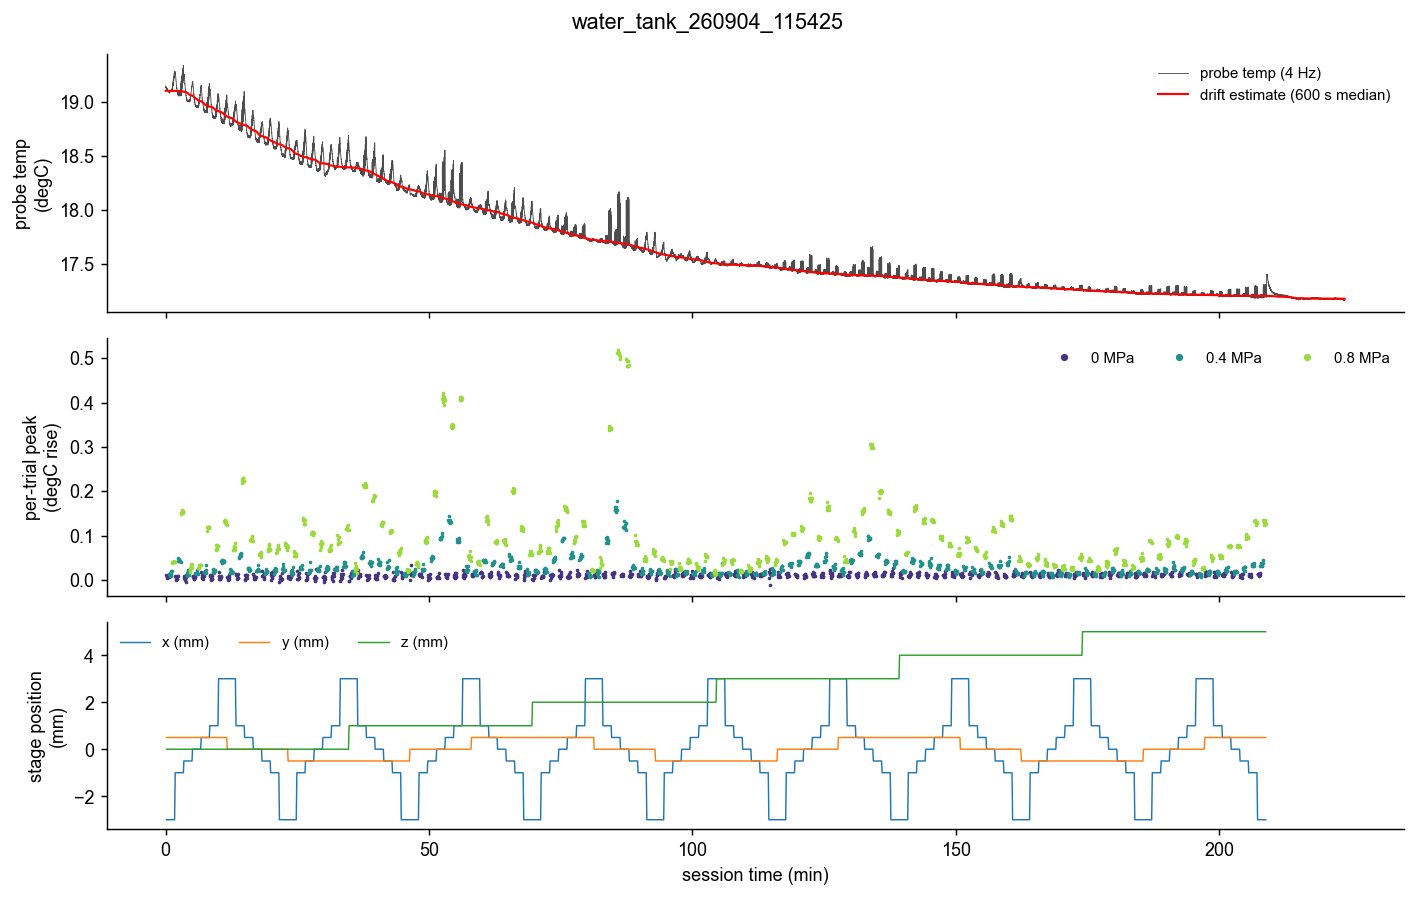

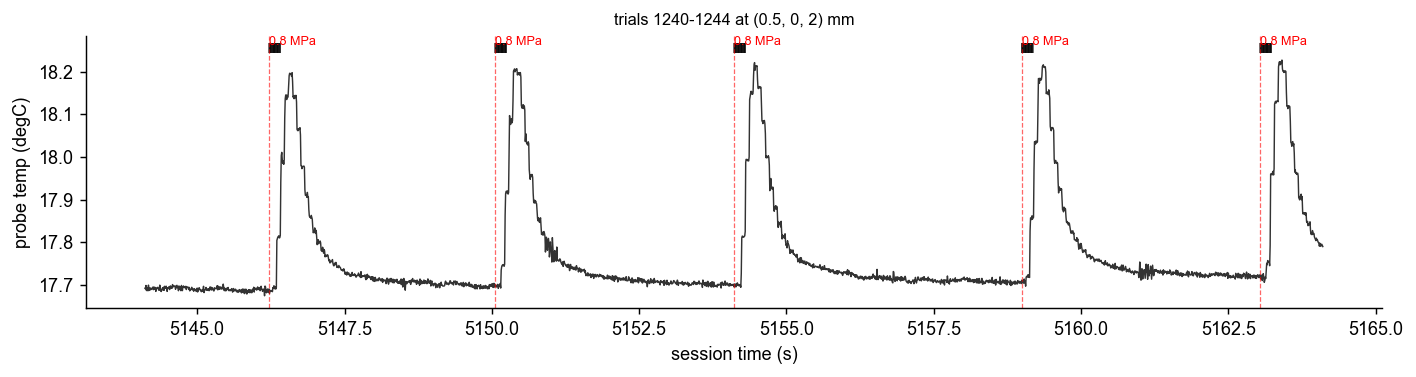

In [9]:
overview_bin = max(int(round(ds_fs / OVERVIEW_FS)), 1)
n_overview = temp_ds.size // overview_bin
t_ov = t_ds[:n_overview * overview_bin].reshape(n_overview, overview_bin).mean(axis=1)
temp_ov = temp_ds[:n_overview * overview_bin].reshape(n_overview, overview_bin).mean(axis=1)
drift = ndimage.median_filter(temp_ov, size=int(round(BASELINE_WINDOW * OVERVIEW_FS)), mode='reflect')  # Baseline estimate

post = t_window >= 0
trial_peaks = np.nanmax(trials[:, post], axis=1)
pressures = axis_values[P_KEY]
pressure_color = {p: plt.get_cmap('viridis')(0.15 + 0.7 * i / max(len(pressures) - 1, 1))
                  for i, p in enumerate(pressures)}

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 7), dpi=130,
                         gridspec_kw=dict(height_ratios=[2, 2, 1.6]))

axes[0].plot(t_ov / 60, temp_ov, lw=0.5, color='0.3', label=f'probe temp ({OVERVIEW_FS} Hz)')
axes[0].plot(t_ov / 60, drift, lw=1.2, color='r', label=f'drift estimate ({BASELINE_WINDOW:g} s median)')
axes[0].set_ylabel('probe temp\n(degC)')
axes[0].legend(fontsize='small', frameon=False)

for pressure, color in pressure_color.items():
    m = np.round(table[P_KEY], 6) == pressure
    axes[1].plot(onset_times[m] / 60, trial_peaks[m], '.', ms=2, color=color, label=f'{pressure:g} MPa')
axes[1].set_ylabel('per-trial peak\n(degC rise)')
axes[1].legend(fontsize='small', frameon=False, ncol=len(pressure_color), markerscale=3)

for key in (X_KEY, Y_KEY, Z_KEY):
    axes[2].plot(onset_times / 60, table[key], lw=0.8, label=key)
axes[2].set_ylabel('stage position\n(mm)')
axes[2].legend(fontsize='small', frameon=False, ncol=3)
axes[2].set_xlabel('session time (min)')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
fig.suptitle(os.path.basename(PATH))
fig.tight_layout()
plt.show()

# A few consecutive trials for triage
zoom_span = 20.0  # s
zoom_center = onset_times[np.nanargmax(trial_peaks)]
m = (t_ds >= zoom_center - zoom_span / 2) & (t_ds <= zoom_center + zoom_span / 2)
shown = np.where((onset_times >= t_ds[m][0]) & (onset_times <= t_ds[m][-1]))[0]

fig, ax = plt.subplots(figsize=(11, 3), dpi=130)
ax.plot(t_ds[m], temp_ds[m], lw=0.8, color='0.2')
tick_y = temp_ds[m].max() + 0.05 * np.ptp(temp_ds[m])
for i in shown:
    pulses = onset_times[i] + pulse_offsets[i]
    ax.plot(pulses, np.full_like(pulses, tick_y), 'k|', ms=6, alpha=0.6)
    ax.axvline(onset_times[i], color='r', ls='--', lw=0.7, alpha=0.6)
    ax.annotate(f'{table[P_KEY][i]:g} MPa', (onset_times[i], tick_y), fontsize=7,
                ha='left', va='bottom', color='r')
ax.set_xlabel('session time (s)')
ax.set_ylabel('probe temp (degC)')
ax.set_title(f'trials {shown.min()}-{shown.max()} at ({table[X_KEY][shown[0]]:g}, '
             f'{table[Y_KEY][shown[0]]:g}, {table[Z_KEY][shown[0]]:g}) mm', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
plt.show()

In [ ]:
# Triggered averages

GRID_KEYS = [k for k in (P_KEY, GRID_PAGE_KEY, GRID_ROW_KEY, GRID_COL_KEY) if k is not None]
grid_columns = [np.round(table[k], 6) for k in GRID_KEYS]

conditions = {}
for i in np.where(valid)[0]:
    conditions.setdefault(tuple(float(c[i]) for c in grid_columns), []).append(i)

t_post = t_window[post]
averages = {}
for condition, idx in conditions.items():
    block = trials[idx]
    mean = block.mean(axis=0)
    popt = fit_double_exp(t_window, mean)
    averages[condition] = dict(
        idx=np.array(idx), n=len(idx), trials=block, mean=mean,
        peak=mean[post].max(), t_peak=t_post[np.argmax(mean[post])], fit_popt=popt,
        fit_r2=(1 - (mean - double_exp_peak(t_window, *popt)).var() / mean.var()
                if popt is not None else np.nan))

print(f'{len(averages)} conditions over {" x ".join(f"{len(axis_values[k])} {k}" for k in GRID_KEYS)}, '
      f'{min(a["n"] for a in averages.values())}-{max(a["n"] for a in averages.values())} trials each')

# Per figure scaling
GRID_YLIM = (min(a['mean'].min() for a in averages.values()) - 0.02,
             max(a['mean'].max() for a in averages.values()) * 1.15)

378 conditions over 3 P (MPa) x 3 y (mm) x 6 z (mm) x 7 x (mm), 8-8 trials each


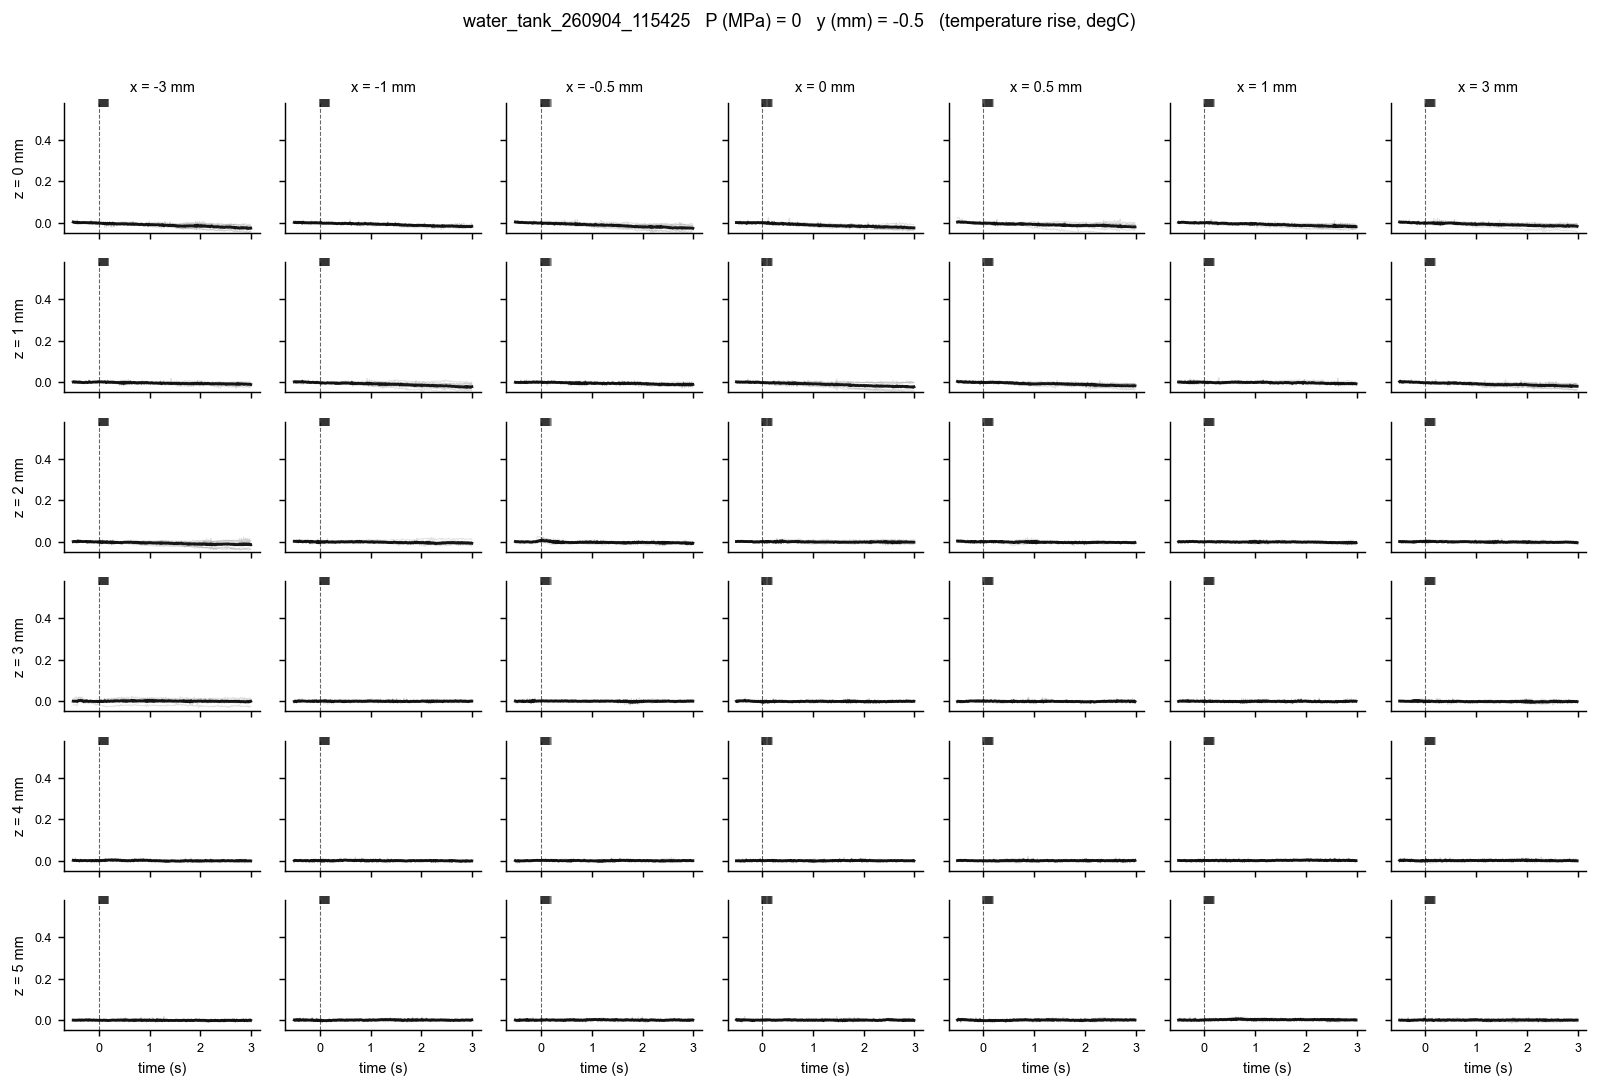

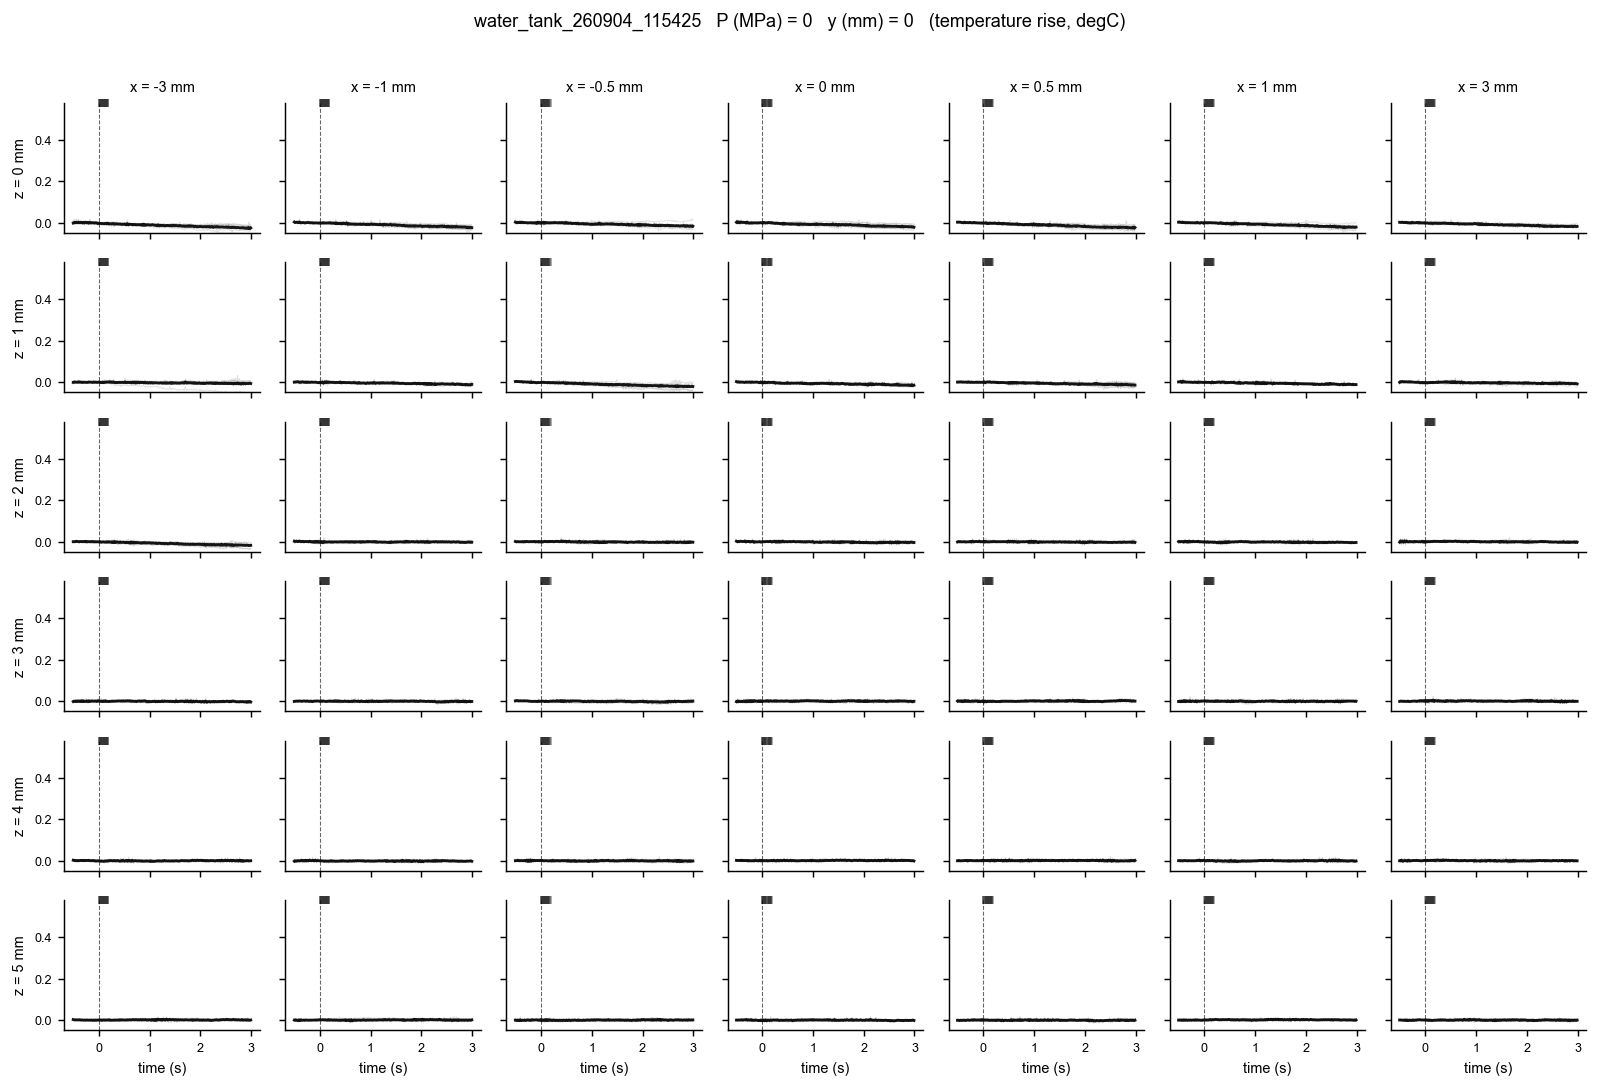

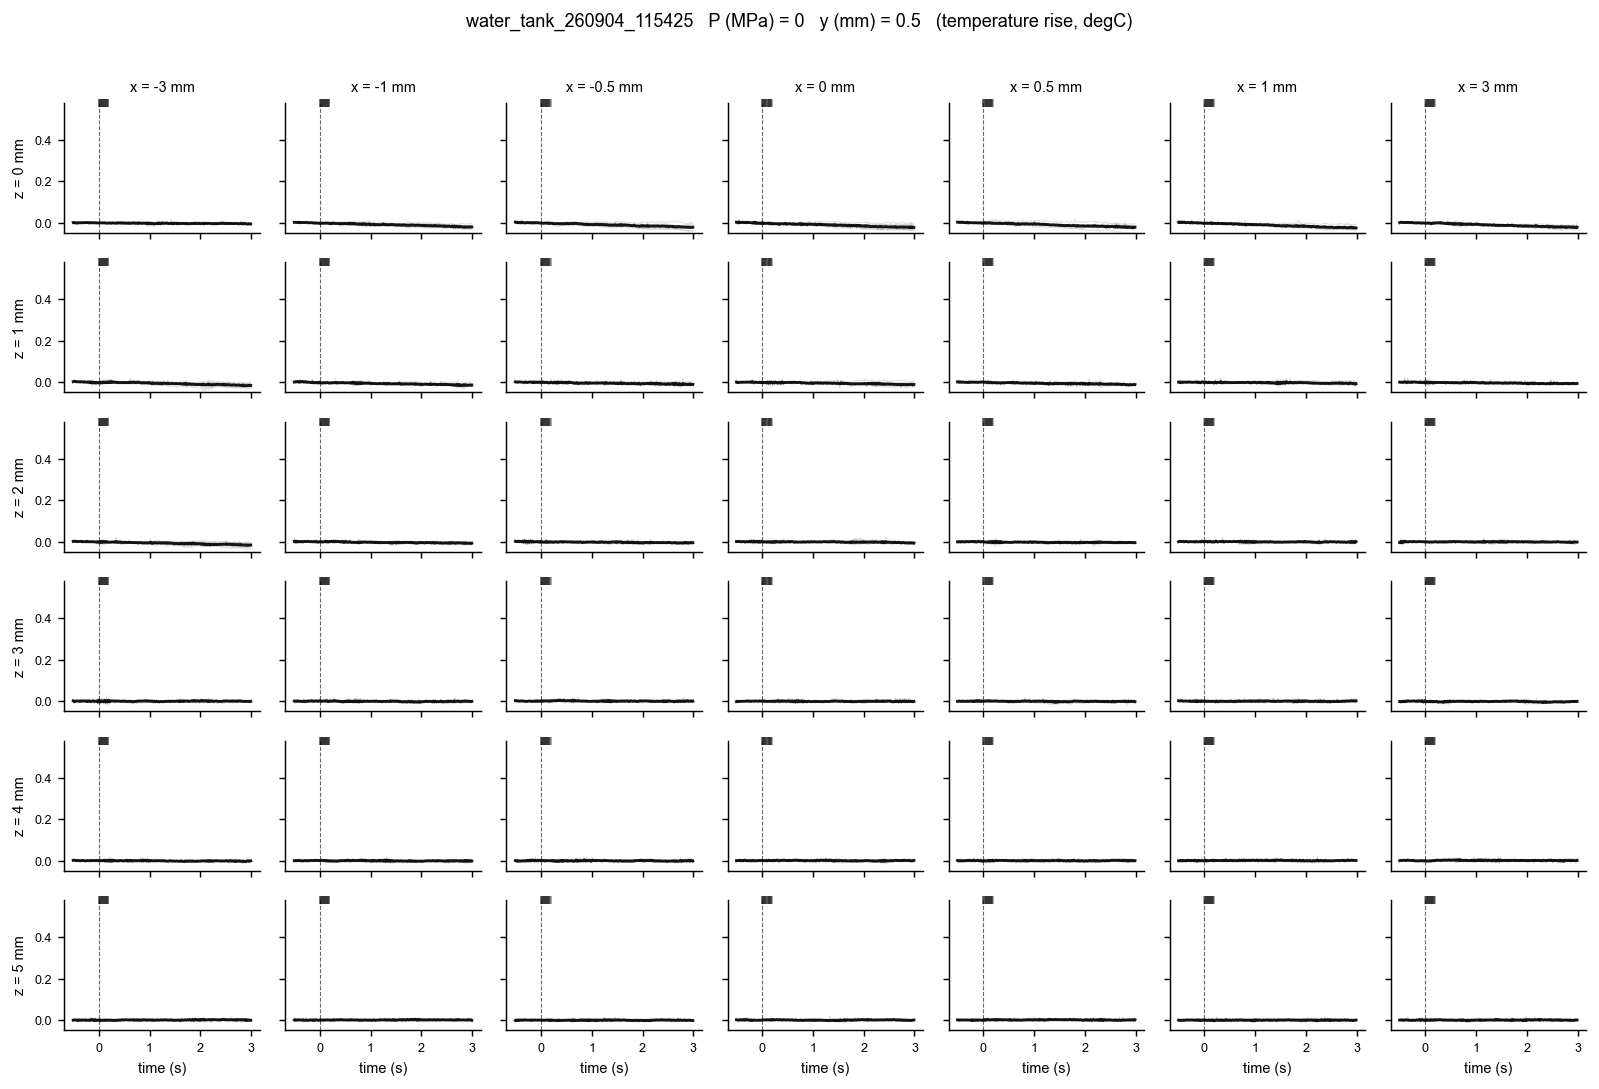

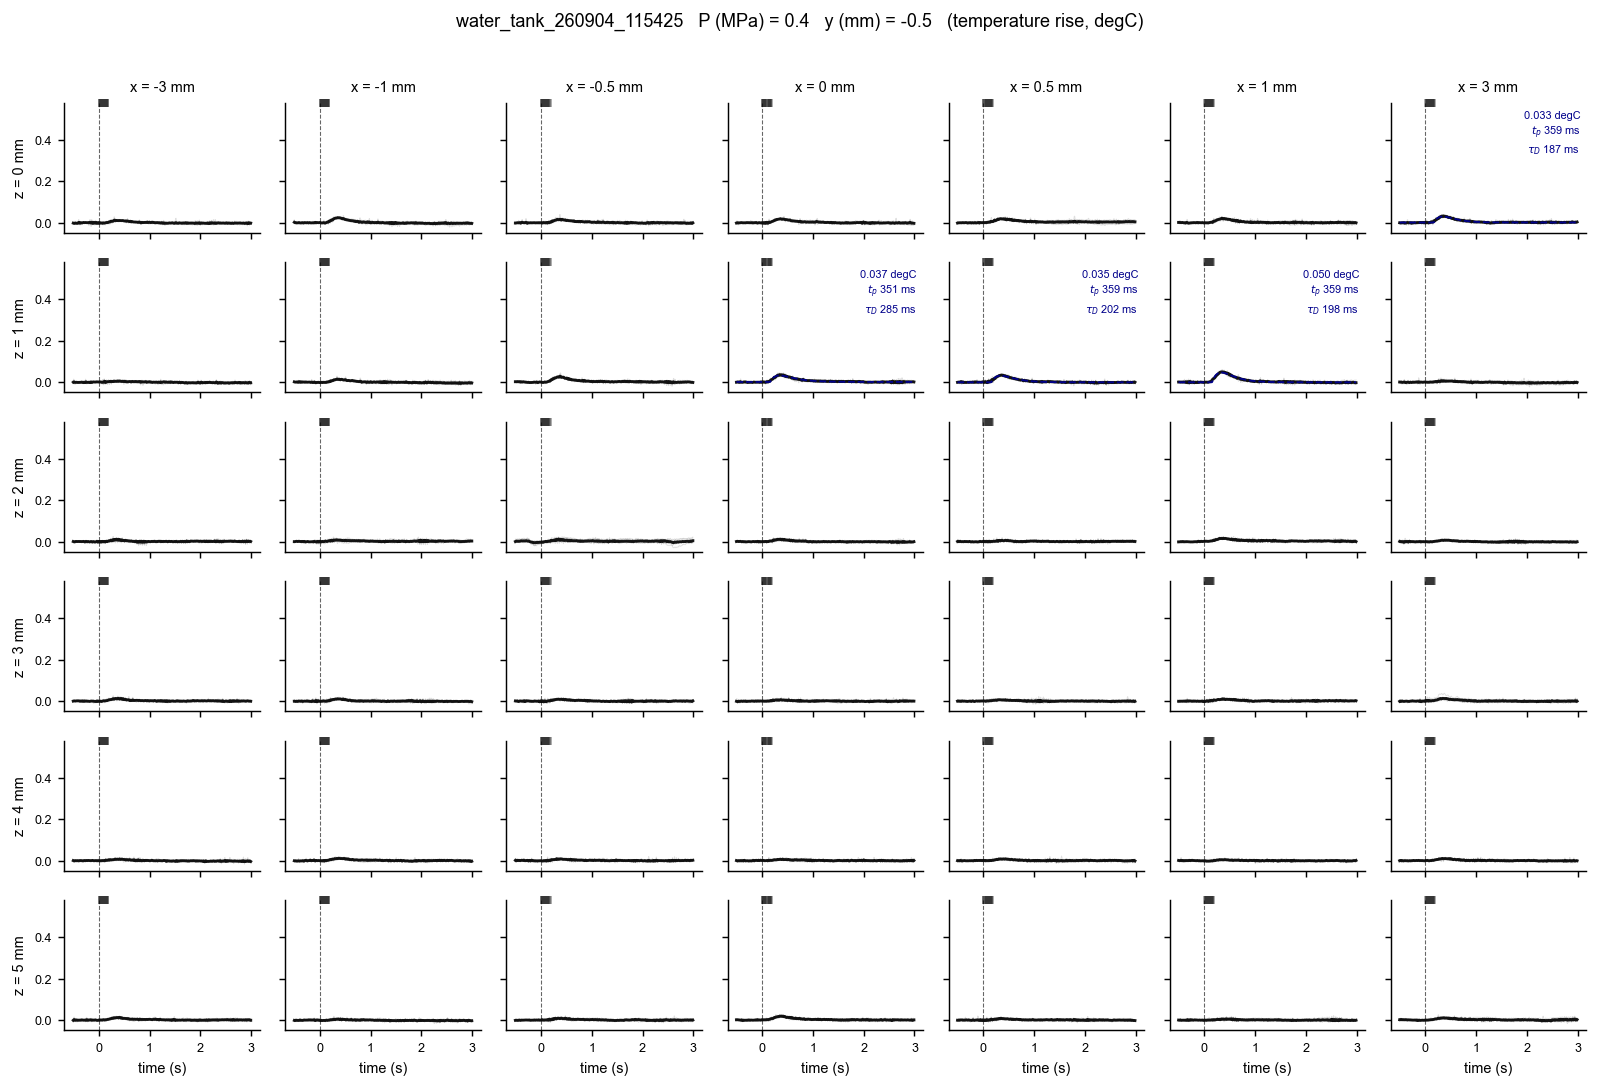

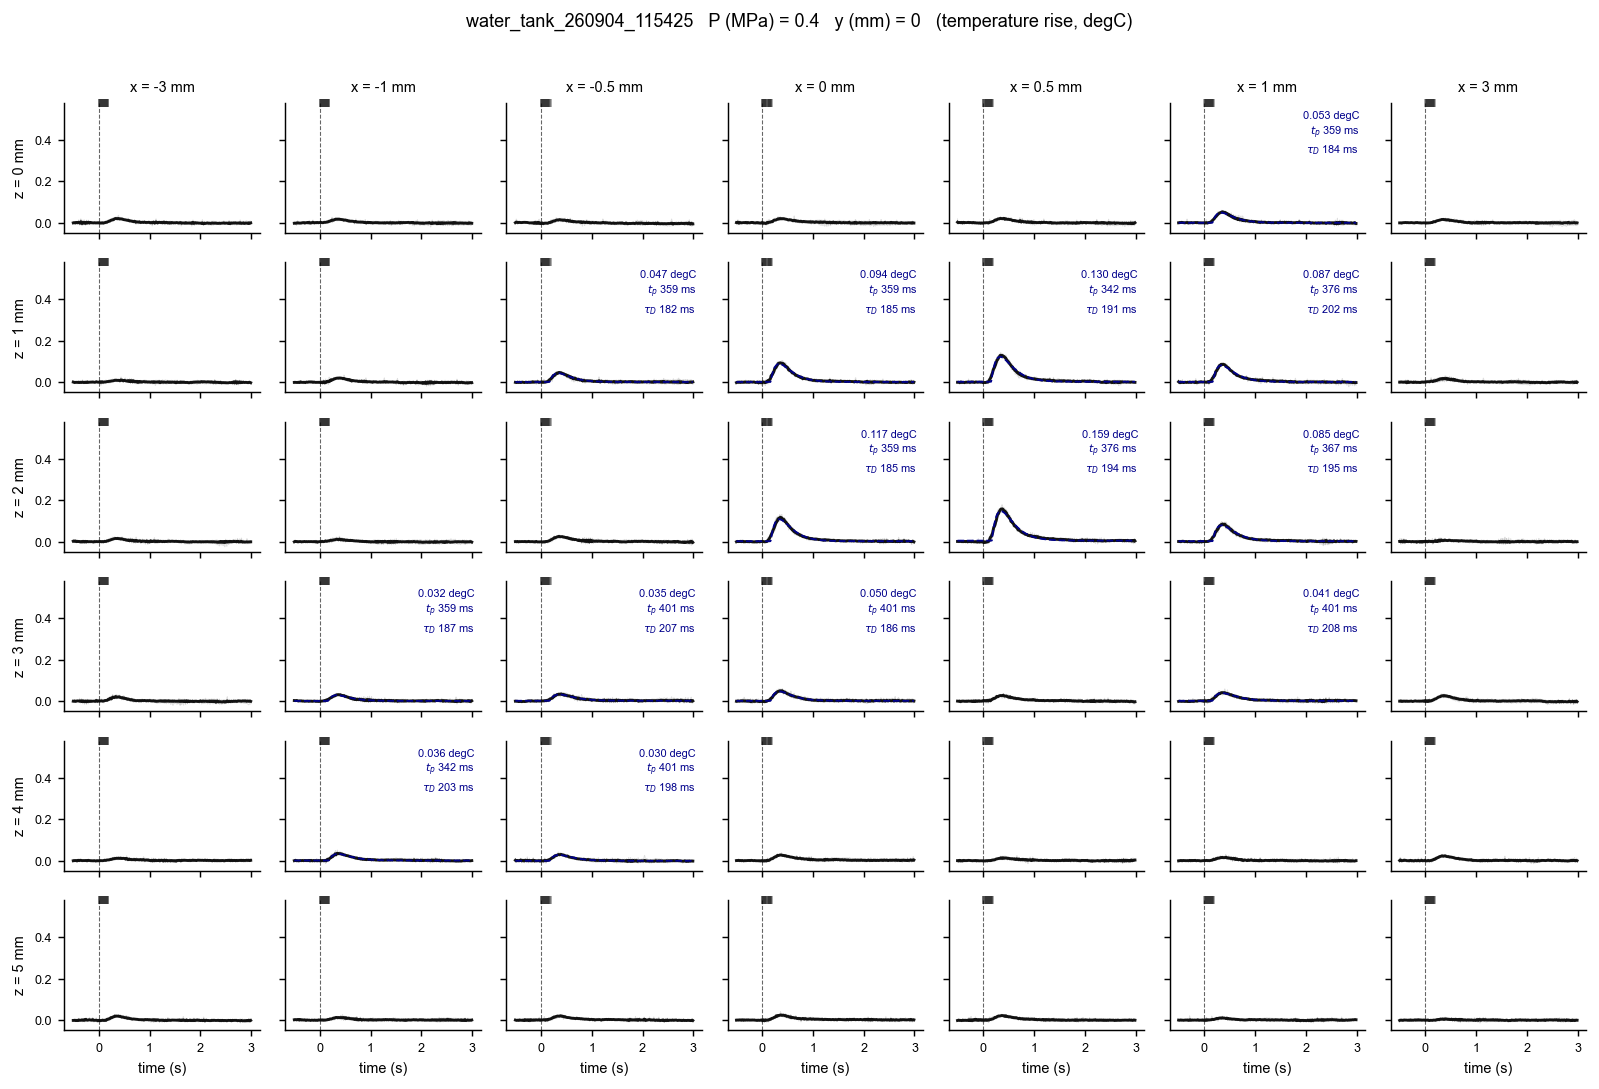

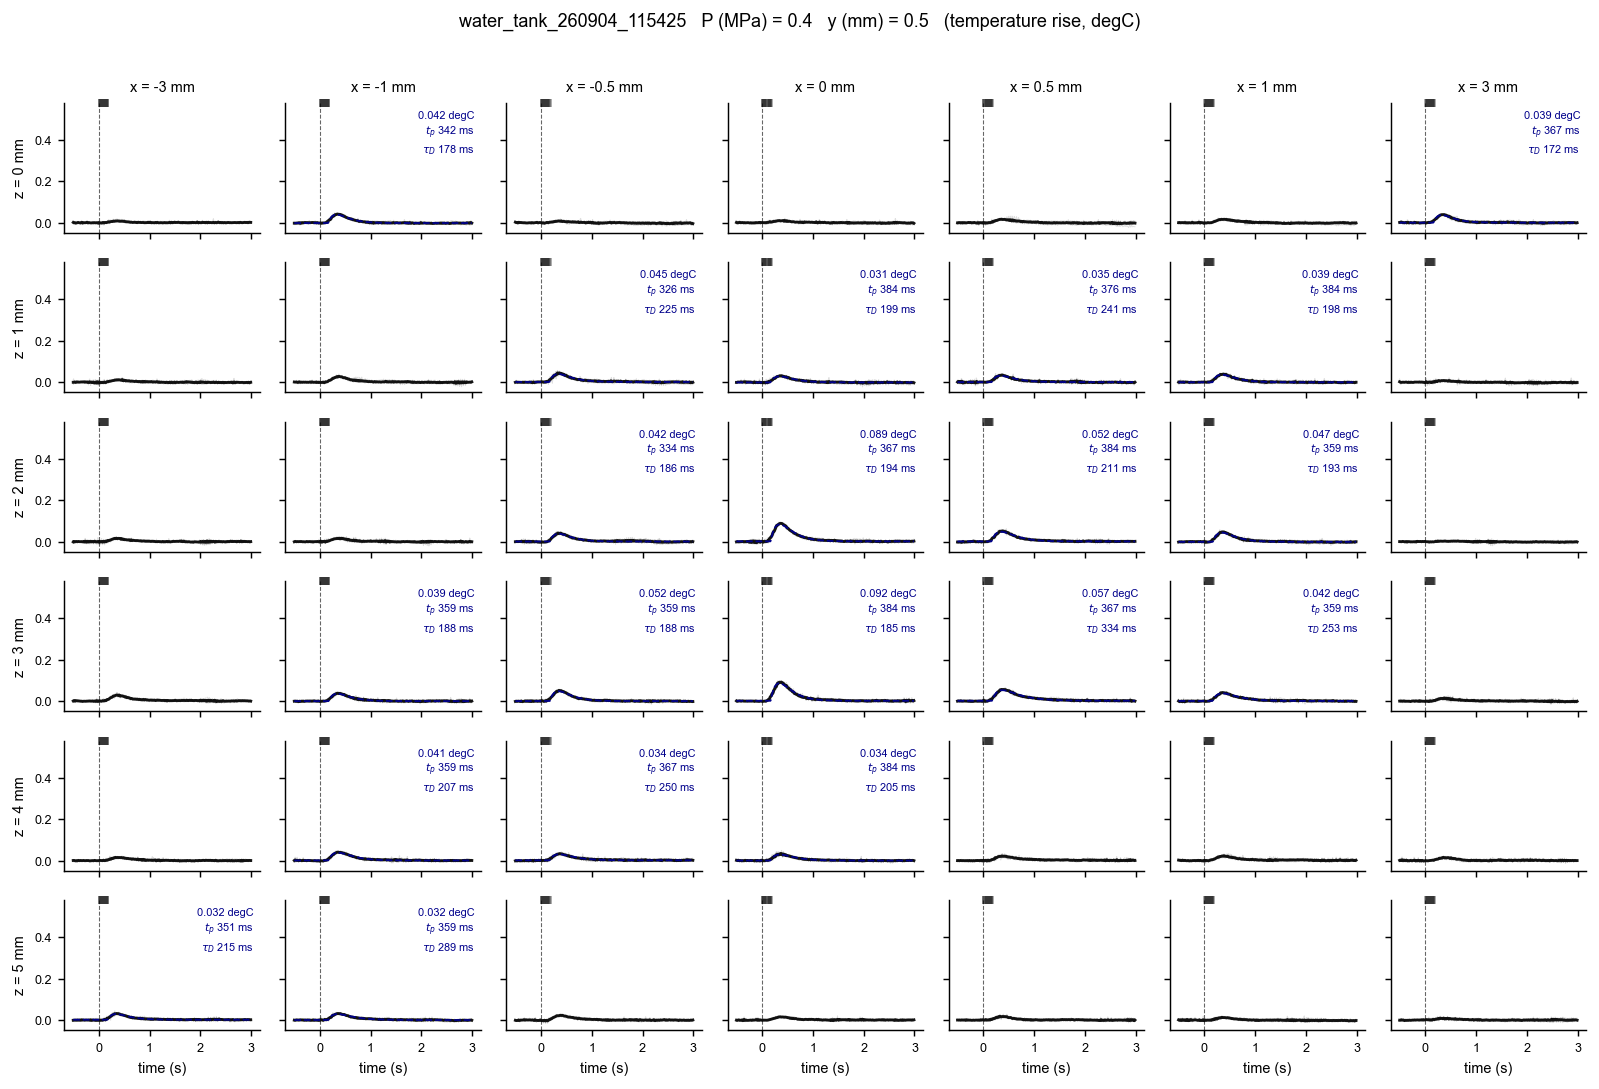

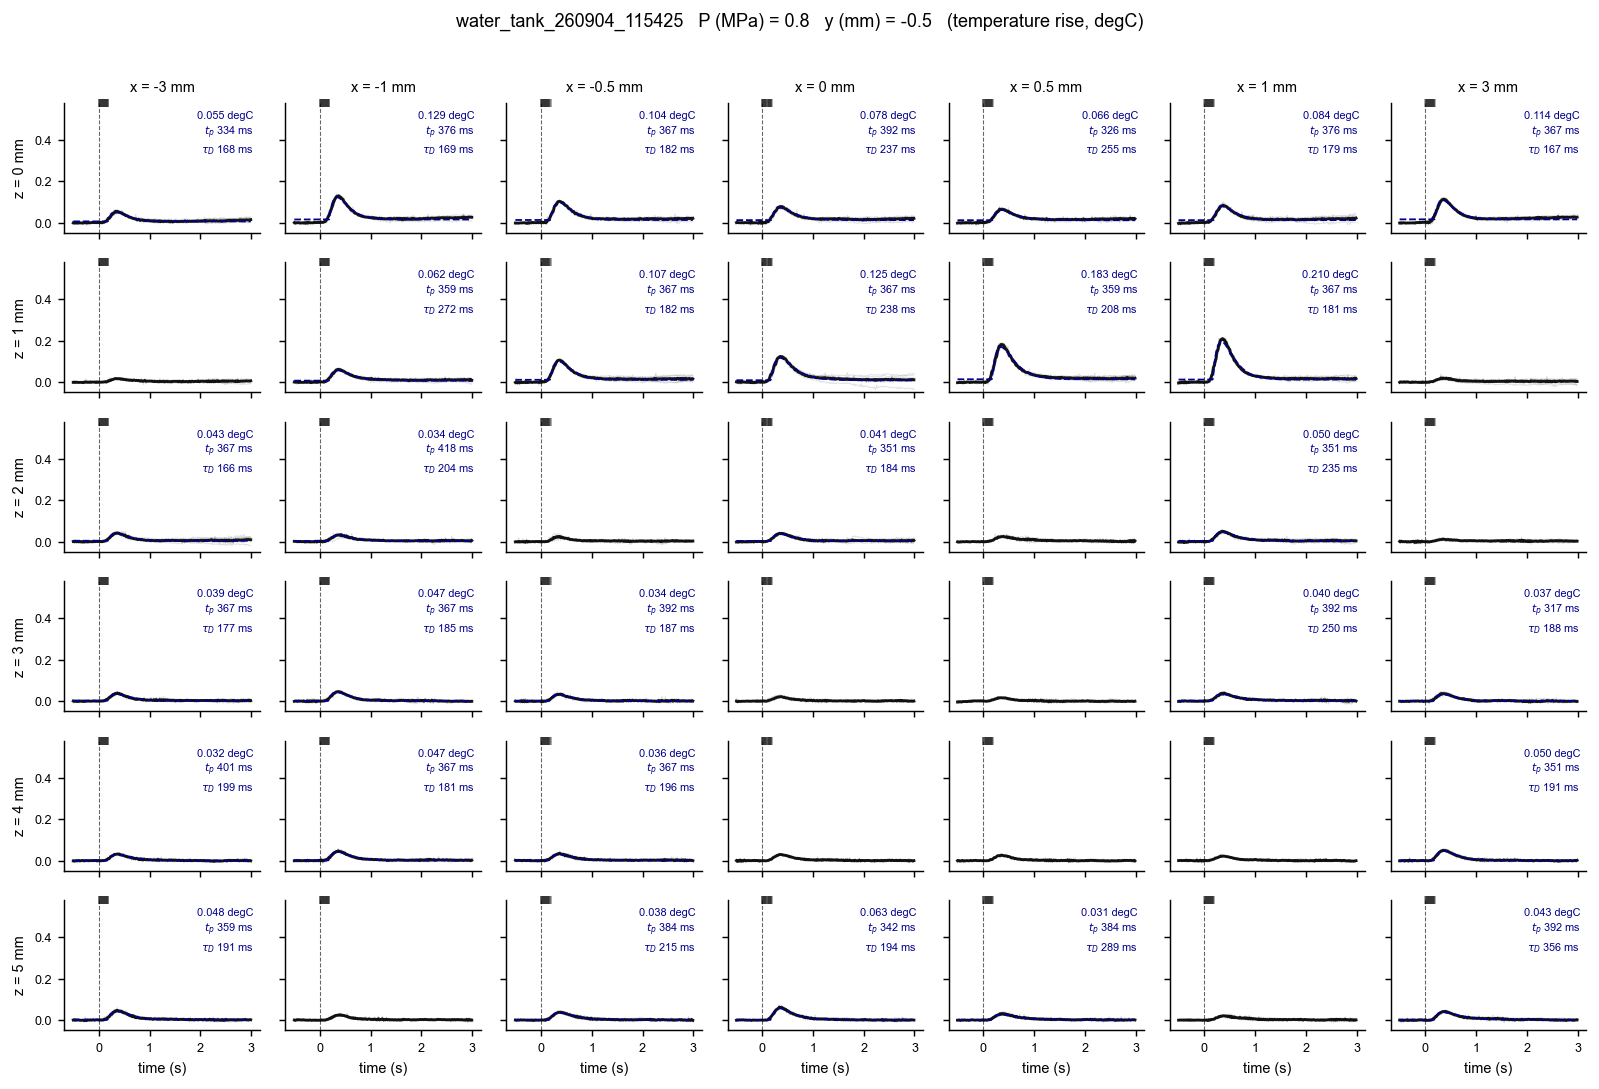

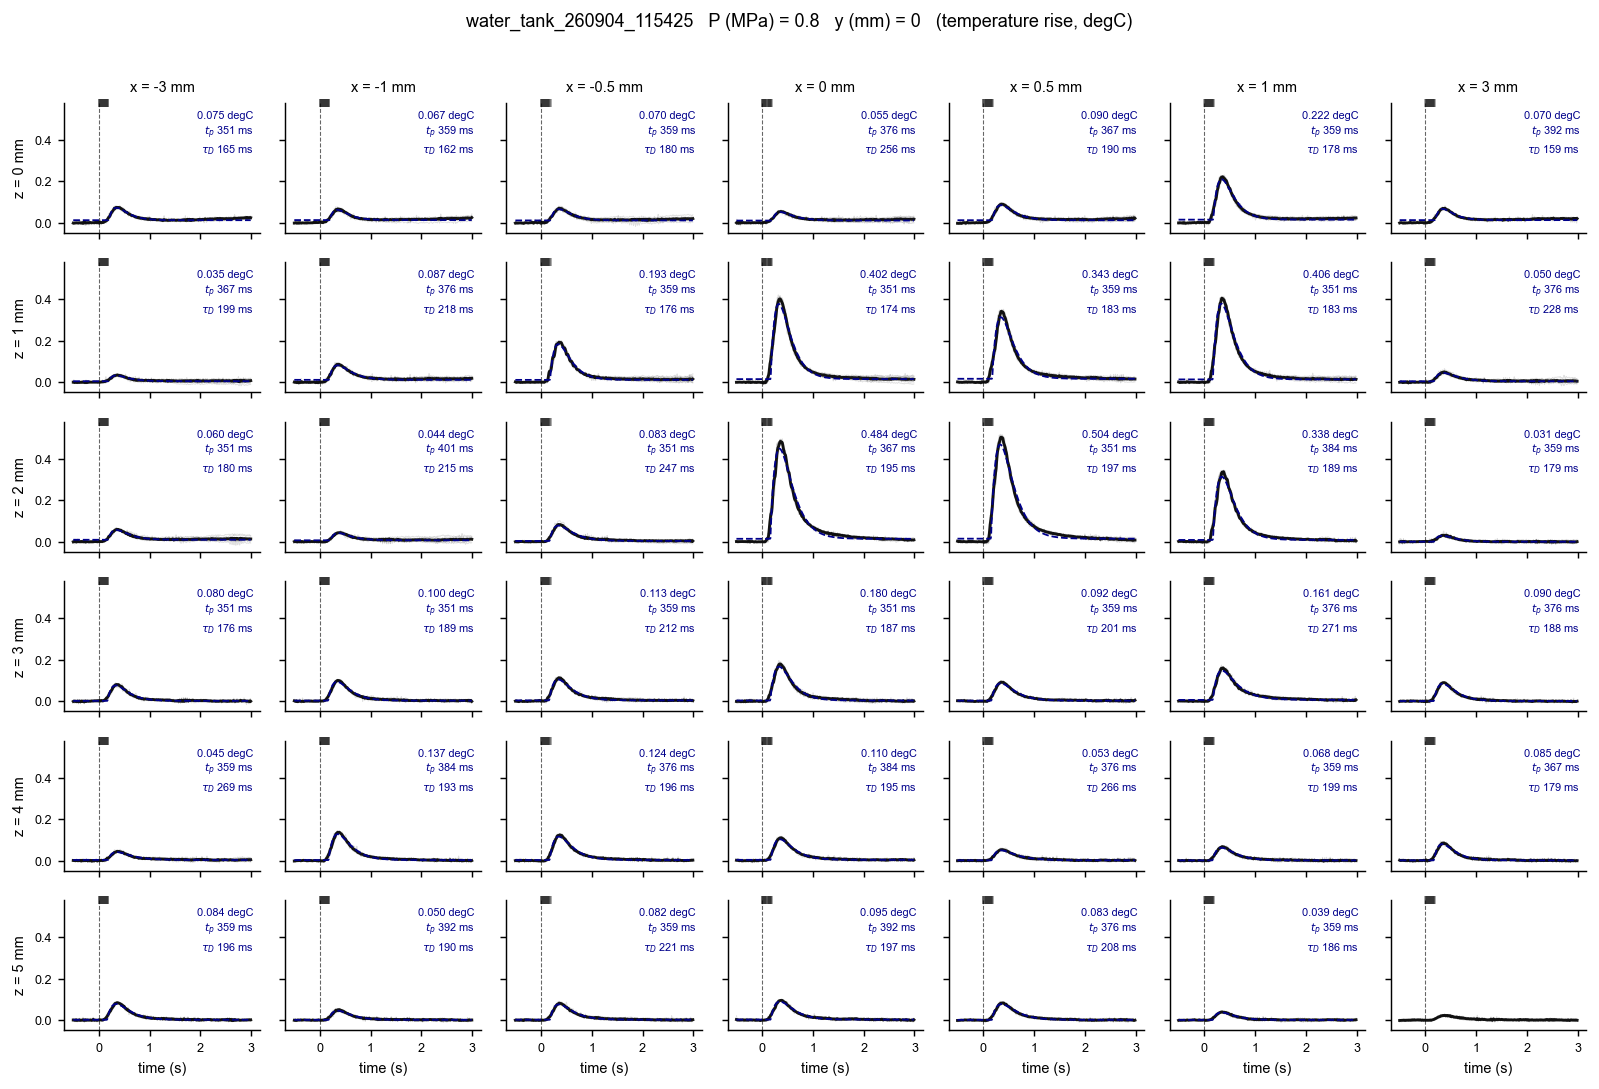

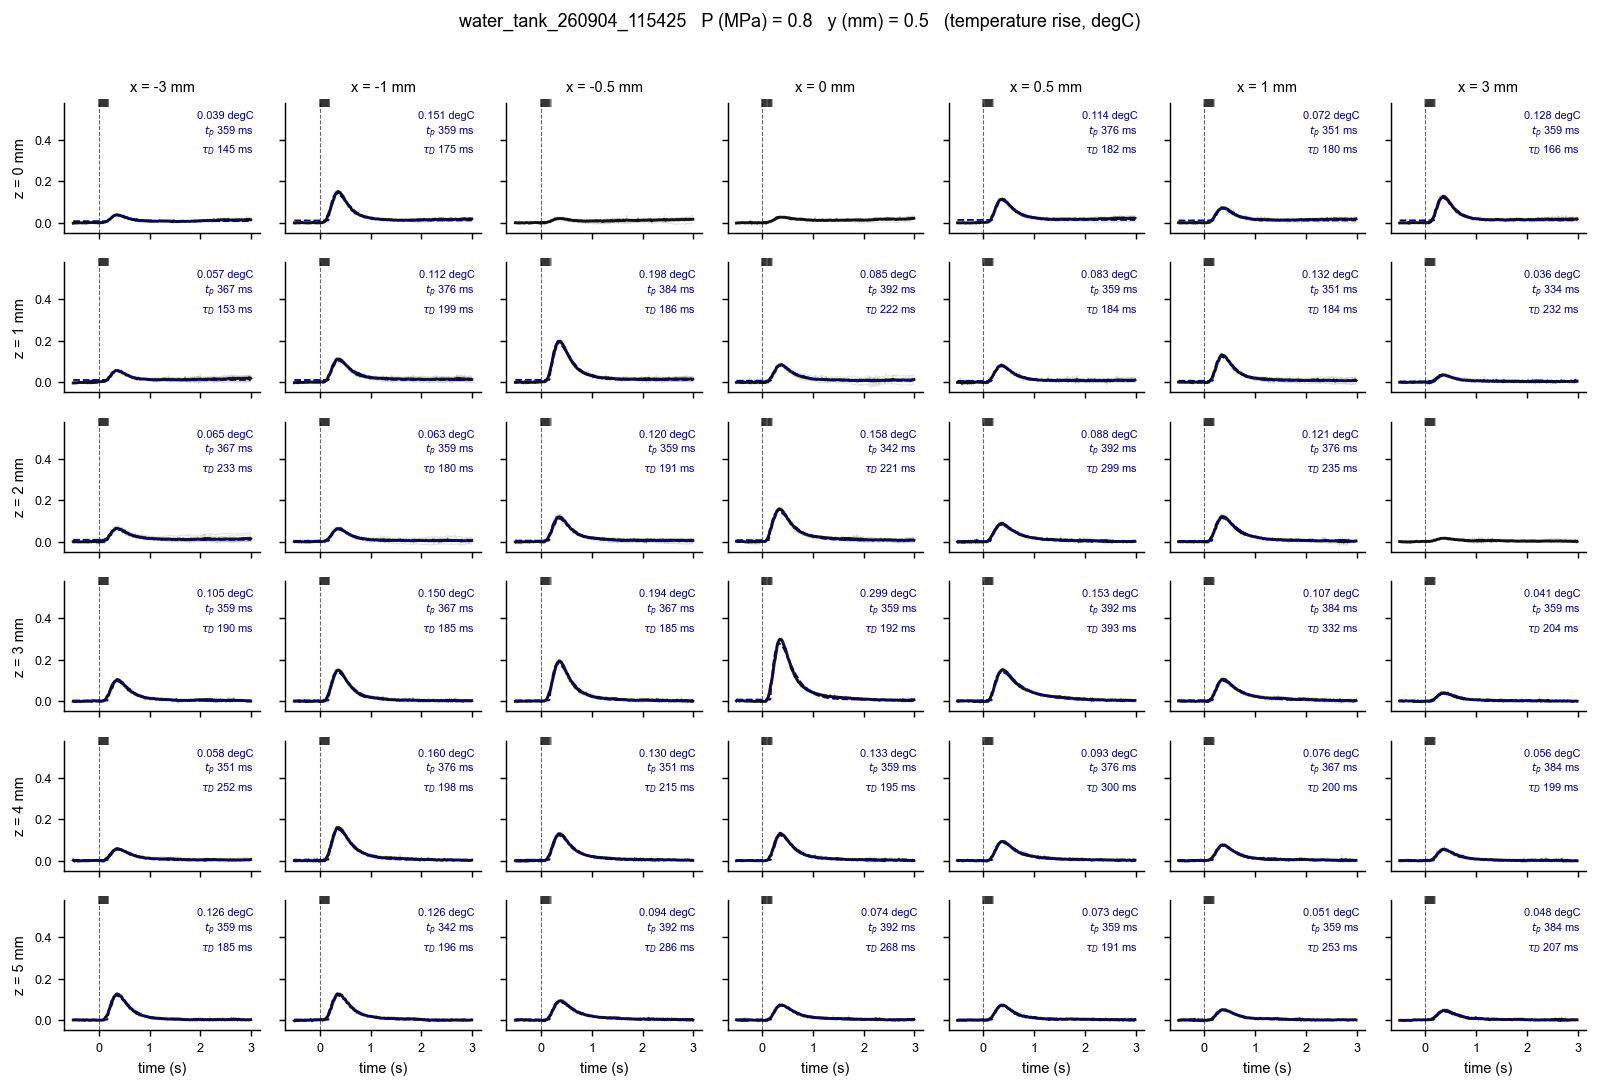

In [11]:
grid_rows = axis_values[GRID_ROW_KEY]
grid_cols = axis_values[GRID_COL_KEY]
grid_pages = axis_values[GRID_PAGE_KEY] if GRID_PAGE_KEY else [None]

for pressure in axis_values[P_KEY]:
    for page_value in grid_pages:
        fig, axes = plt.subplots(len(grid_rows), len(grid_cols), sharex=True, sharey=True,
                                 squeeze=False, dpi=130,
                                 figsize=(1.6 * len(grid_cols) + 1.2, 1.25 * len(grid_rows) + 1.0))
        if GRID_YLIM is not None:
            axes[0, 0].set_ylim(*GRID_YLIM)

        for r, row_value in enumerate(grid_rows):
            for c, col_value in enumerate(grid_cols):
                ax = axes[r, c]
                swept = dict(zip((P_KEY, GRID_PAGE_KEY, GRID_ROW_KEY, GRID_COL_KEY),
                                 (pressure, page_value, row_value, col_value)))
                average = averages.get(tuple(swept[k] for k in GRID_KEYS))
                if average is None:
                    ax.set_visible(False)
                    continue

                # Pulse ticks ride the top of the panel in axes coordinates, so
                # they stay put whatever the shared y limits end up being.
                pulses = pulse_offsets[average['idx'][0]]
                ax.plot(pulses, np.ones_like(pulses), 'k|', ms=4, alpha=0.35, clip_on=False,
                        transform=ax.get_xaxis_transform())
                ax.plot(t_window, average['trials'].T, color='grey', alpha=0.25, lw=0.5)
                ax.plot(t_window, average['mean'], color='black', lw=1.6, alpha=0.9)
                if average['fit_popt'] is not None:
                    ax.plot(t_window, double_exp_peak(t_window, *average['fit_popt']),
                            color='darkblue', lw=1.0, ls='--')
                ax.axvline(0, color='k', ls='--', lw=0.6, alpha=0.6)

                if average['peak'] > FIT_MIN_AMPLITUDE_C:
                    text = f'{average["peak"]:.3f} degC\n$t_p$ {average["t_peak"] * 1000:.0f} ms'
                    if average['fit_popt'] is not None:
                        text += f'\n$\\tau_D$ {average["fit_popt"][3] * 1000:.0f} ms'
                    ax.text(0.97, 0.94, text, transform=ax.transAxes, ha='right', va='top',
                            fontsize=6, color='darkblue', linespacing=1.3)

                ax.tick_params(labelsize=7)
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                if r == 0:
                    ax.set_title(f'{GRID_COL_KEY.split(" ")[0]} = {col_value:g} mm', fontsize=8)
                if c == 0:
                    ax.set_ylabel(f'{GRID_ROW_KEY.split(" ")[0]} = {row_value:g} mm', fontsize=8)
                if r == len(grid_rows) - 1:
                    ax.set_xlabel('time (s)', fontsize=8)

        title = f'{os.path.basename(PATH)}   {P_KEY} = {pressure:g}'
        if page_value is not None:
            title += f'   {GRID_PAGE_KEY} = {page_value:g}'
        fig.suptitle(title + '   (temperature rise, degC)', fontsize=10)
        fig.tight_layout(rect=(0, 0, 1, 0.97))
        plt.show()

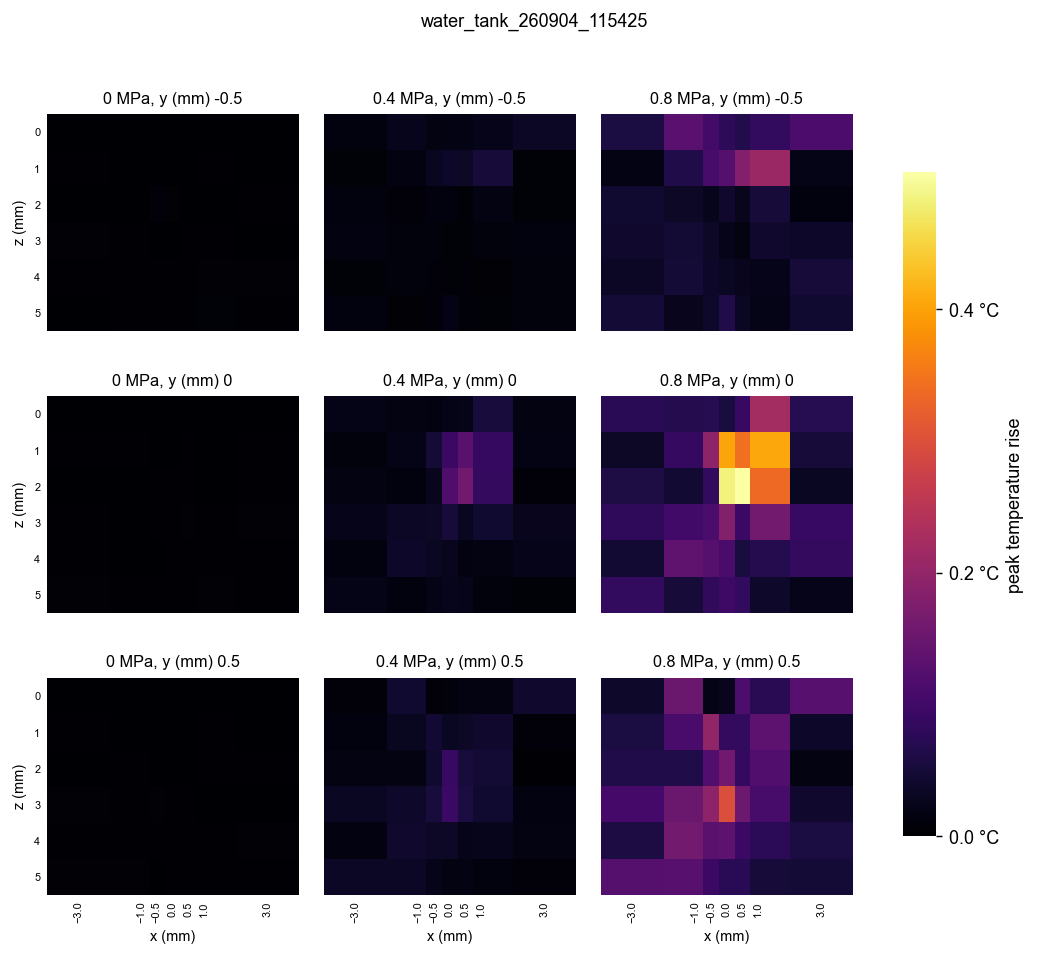


0 MPa sham peaks: mean 0.002 degC, 95th pct 0.004 degC (noise floor for the maps above)


In [15]:
# ------------------------------------------------------- response maps ----
# The same sweep condensed to where in the tank the probe actually heats: peak
# temperature rise per position, one column per pressure, one row per
# GRID_PAGE_KEY slice. Drawn with pcolormesh on the real stage coordinates
# rather than imshow, because the sampling is deliberately uneven (x is -3, -1,
# -0.5, 0, 0.5, 1, 3 mm -- fine around the focus, coarse outside it) and
# equal-width pixels would misrepresent the geometry. Swap 'peak' below for a
# fit parameter, e.g. average['fit_popt'][3], to map tau_decay instead.

peak_maps = {}
for pressure in axis_values[P_KEY]:
    for page_value in grid_pages:
        grid = np.full((grid_rows.size, grid_cols.size), np.nan)
        for r, row_value in enumerate(grid_rows):
            for c, col_value in enumerate(grid_cols):
                swept = dict(zip((P_KEY, GRID_PAGE_KEY, GRID_ROW_KEY, GRID_COL_KEY),
                                 (pressure, page_value, row_value, col_value)))
                average = averages.get(tuple(swept[k] for k in GRID_KEYS))
                if average is not None:
                    grid[r, c] = average['peak']
        peak_maps[(pressure, page_value)] = grid

# Cell boundaries for unevenly spaced sample positions: midpoints between
# neighbours, with half a step added at each end.
col_mid = (grid_cols[:-1] + grid_cols[1:]) / 2
row_mid = (grid_rows[:-1] + grid_rows[1:]) / 2
col_edges = np.concatenate(([2 * grid_cols[0] - col_mid[0]], col_mid, [2 * grid_cols[-1] - col_mid[-1]]))
row_edges = np.concatenate(([2 * grid_rows[0] - row_mid[0]], row_mid, [2 * grid_rows[-1] - row_mid[-1]]))

fig, axes = plt.subplots(len(grid_pages), len(axis_values[P_KEY]), squeeze=False, dpi=130,
                         sharex=True, sharey=True, gridspec_kw=dict(hspace=0.3, wspace=0.1),
                         figsize=(3.0 * len(axis_values[P_KEY]) + 1.0, 2.6 * len(grid_pages)))
vmax = np.nanmax(list(peak_maps.values()))

# Colorbar ticks at round temperatures
cbar_ticks = ticker.MaxNLocator(nbins=5, steps=[1, 2, 2.5, 5, 10]).tick_values(0, vmax)
cbar_ticks = cbar_ticks[(cbar_ticks >= 0) & (cbar_ticks <= vmax)]
cbar_decimals = max(0, -int(np.floor(np.log10(np.diff(cbar_ticks).min()))))
cbar_format = ticker.FormatStrFormatter(f'%.{cbar_decimals}f °C')

for gi, page_value in enumerate(grid_pages):
    for pi, pressure in enumerate(axis_values[P_KEY]):
        ax = axes[gi, pi]
        mesh = ax.pcolormesh(col_edges, row_edges, peak_maps[(pressure, page_value)],
                             cmap='inferno', vmin=0, vmax=vmax, shading='flat')
        ax.set_xticks(grid_cols)
        ax.set_yticks(grid_rows)
        ax.tick_params(labelsize=6, length=0)
        plt.setp(ax.get_xticklabels(), rotation=90)
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title(f'{pressure:g} MPa' + (f', {GRID_PAGE_KEY} {page_value:g}'
                                            if page_value is not None else ''), fontsize=9)
        if pi == 0:
            ax.set_ylabel(GRID_ROW_KEY, fontsize=8)
        if gi == len(grid_pages) - 1:
            ax.set_xlabel(GRID_COL_KEY, fontsize=8)

axes[0, 0].invert_yaxis()  # depth increases downwards (axes are shared, so once is enough)
cbar = fig.colorbar(mesh, ax=axes, shrink=0.85, label='peak temperature rise',
                    ticks=cbar_ticks, format=cbar_format)
cbar.outline.set_visible(False)
fig.suptitle(os.path.basename(PATH), fontsize=10)
plt.show()

for condition, average in sorted(averages.items(), key=lambda kv: -kv[1]['peak'])[:15]:
    popt = average['fit_popt']
    if popt is None:
        fit = f'{"-":>9}{"-":>9}{"-":>7}'
    else:
        tau_rise = f'{popt[2] * 1000:.0f}' + ('*' if popt[2] >= 0.999 * FIT_MAX_TAU_RISE else '')
        fit = f'{tau_rise:>9}{popt[3] * 1000:9.0f}{average["fit_r2"]:7.3f}'

sham = np.array([a['peak'] for c, a in averages.items() if c[GRID_KEYS.index(P_KEY)] == 0.0])
print(f'\n0 MPa sham peaks: mean {sham.mean():.3f} degC, 95th pct {np.percentile(sham, 95):.3f} degC '
      f'(noise floor for the maps above)')

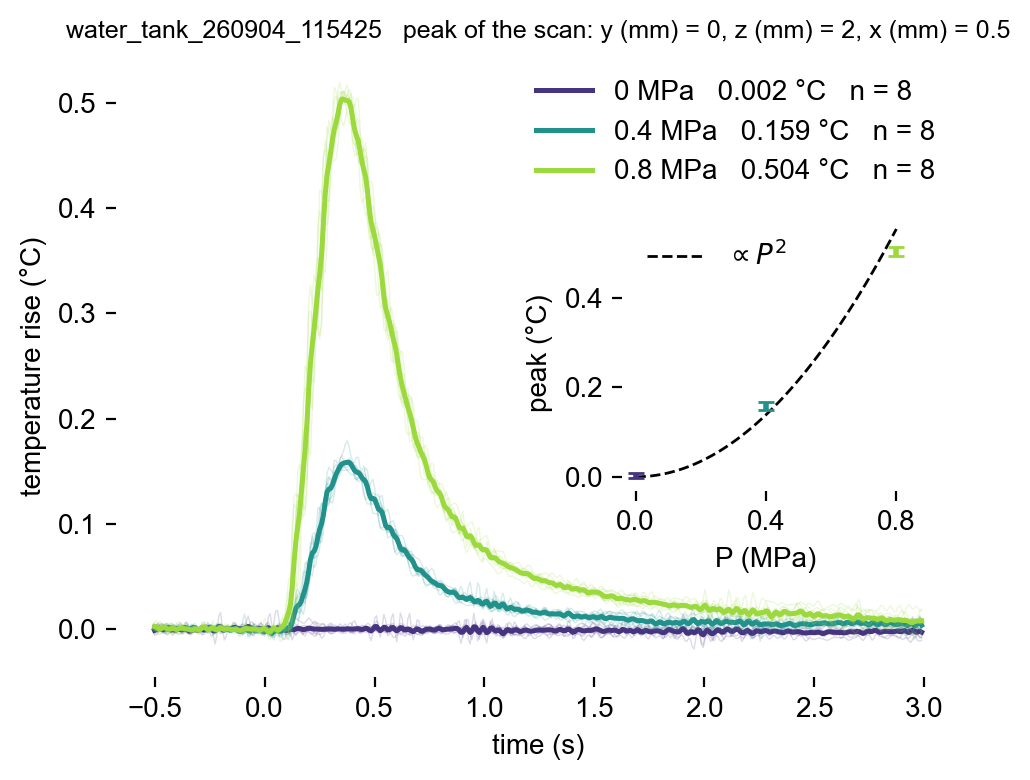

In [21]:
# The pressure ramp read at the location maximized for highest pressure condition

p_index = GRID_KEYS.index(P_KEY)
focus_pressure = max(axis_values[P_KEY])
focus_condition = max((c for c in averages if c[p_index] == focus_pressure),
                      key=lambda c: averages[c]['peak'])
focus_label = ', '.join(f'{k} = {v:g}' for k, v in zip(GRID_KEYS, focus_condition) if k != P_KEY)

fig, ax = plt.subplots(figsize=(5, 4), dpi=200)

focus_peaks = {}
for pressure in axis_values[P_KEY]:
    condition = focus_condition[:p_index] + (pressure,) + focus_condition[p_index + 1:]
    average = averages.get(condition)
    if average is None:
        continue
    focus_peaks[pressure] = average['peak']
    color = pressure_color[pressure]
    ax.plot(t_window, average['trials'].T, color=color, alpha=0.18, lw=0.5)
    ax.plot(t_window, average['mean'], color=color, lw=1.8,
            label=f'{pressure:g} MPa   {average["peak"]:.3f} \N{DEGREE SIGN}C   n = {average["n"]}')

ax.set_xlabel('time (s)')
ax.set_ylabel(f'temperature rise (\N{DEGREE SIGN}C)')
ax.legend(frameon=False, loc='upper right')
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title(f'{os.path.basename(PATH)}   peak of the scan: {focus_label}', fontsize=9)

inset = ax.inset_axes([0.60, 0.30, 0.34, 0.44])
p_measured = np.array(sorted(focus_peaks))
rise_measured = np.array([focus_peaks[p] for p in p_measured])
p_line = np.linspace(0, p_measured.max(), 100)
inset.plot(p_line, 1.1 * rise_measured[-1] * (p_line / p_measured.max()) ** 2,
           color='black', lw=1.0, ls='--', label='$\propto P^2$')
for pressure in p_measured:
    condition = focus_condition[:p_index] + (pressure,) + focus_condition[p_index + 1:]
    average = averages[condition]
    peak_index = np.flatnonzero(post)[np.argmax(average['mean'][post])]
    trial_rises = average['trials'][:, peak_index]
    inset.errorbar(pressure, trial_rises.mean(), yerr=trial_rises.std(ddof=1),
                   color=pressure_color[pressure], marker='None', ms=1.0, lw=2.0,
                   capsize=3, zorder=10)
inset.legend(frameon=False)
inset.plot(p_measured, rise_measured, linestyle='None', color='k', lw=1.0, zorder=0)
inset.set_xlabel(P_KEY)
inset.set_ylabel(f'peak (\N{DEGREE SIGN}C)')
inset.set_xticks(p_measured)
inset.tick_params()
for spine in inset.spines.values():
    spine.set_visible(False)

fig.tight_layout()
plt.show()

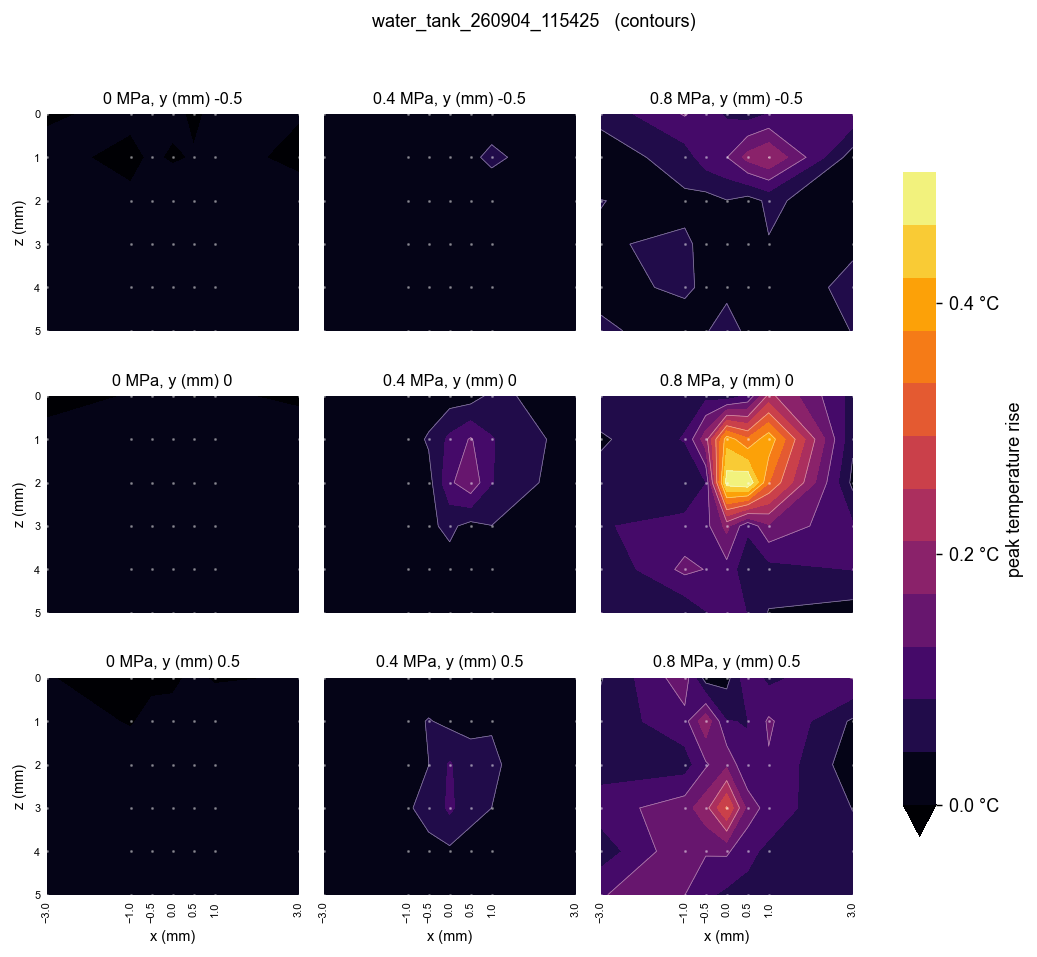

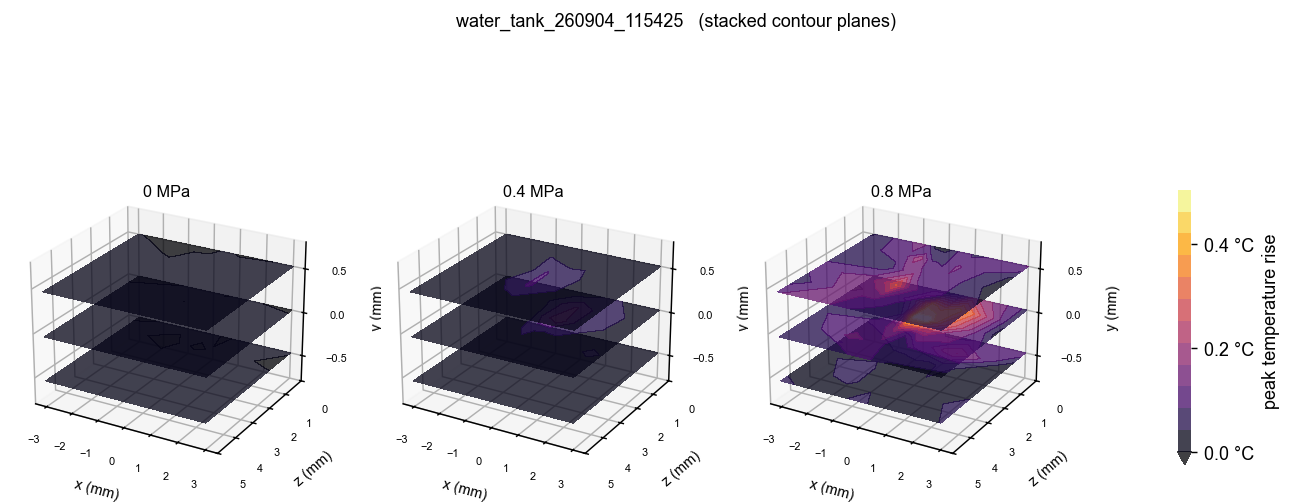

In [19]:
# Contour plots

CONTOUR_LEVELS = np.linspace(0, vmax, 13)
col_grid, row_grid = np.meshgrid(grid_cols, grid_rows)

fig, axes = plt.subplots(len(grid_pages), len(axis_values[P_KEY]), squeeze=False, dpi=130,
                         sharex=True, sharey=True, gridspec_kw=dict(hspace=0.3, wspace=0.1),
                         figsize=(3.0 * len(axis_values[P_KEY]) + 1.0, 2.6 * len(grid_pages)))

for gi, page_value in enumerate(grid_pages):
    for pi, pressure in enumerate(axis_values[P_KEY]):
        ax = axes[gi, pi]
        grid = peak_maps[(pressure, page_value)]
        # extend='min' so the sham panels, which dip a millikelvin below zero,
        # stay filled with the bottom colour instead of going blank.
        filled = ax.contourf(col_grid, row_grid, grid, levels=CONTOUR_LEVELS,
                             cmap='inferno', vmin=0, vmax=vmax, extend='min')
        ax.contour(col_grid, row_grid, grid, levels=CONTOUR_LEVELS[1::2],
                   colors='w', linewidths=0.4, alpha=0.5)
        ax.plot(col_grid, row_grid, 'w.', ms=1.2, alpha=0.4)
        ax.set_xticks(grid_cols)
        ax.set_yticks(grid_rows)
        ax.tick_params(labelsize=6, length=0)
        plt.setp(ax.get_xticklabels(), rotation=90)
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_title(f'{pressure:g} MPa' + (f', {GRID_PAGE_KEY} {page_value:g}'
                                            if page_value is not None else ''), fontsize=9)
        if pi == 0:
            ax.set_ylabel(GRID_ROW_KEY, fontsize=8)
        if gi == len(grid_pages) - 1:
            ax.set_xlabel(GRID_COL_KEY, fontsize=8)

axes[0, 0].invert_yaxis()  # depth increases downwards (axes are shared)
cbar = fig.colorbar(filled, ax=axes, shrink=0.85, label='peak temperature rise',
                    ticks=cbar_ticks, format=cbar_format)
cbar.outline.set_visible(False)
fig.suptitle(os.path.basename(PATH) + '   (contours)', fontsize=10)
plt.show()

# 3D contours

page_coords = np.array([0.0 if v is None else float(v) for v in grid_pages])
page_span = max(np.ptp(page_coords), 1e-6)

fig = plt.figure(figsize=(4.2 * len(axis_values[P_KEY]) + 1.0, 5.0), dpi=130)
for pi, pressure in enumerate(axis_values[P_KEY]):
    ax = fig.add_subplot(1, len(axis_values[P_KEY]), pi + 1, projection='3d')
    for page_value, page_coord in zip(grid_pages, page_coords):
        filled = ax.contourf(col_grid, row_grid, peak_maps[(pressure, page_value)],
                             zdir='z', offset=page_coord, levels=CONTOUR_LEVELS,
                             cmap='inferno', vmin=0, vmax=vmax, extend='min', alpha=0.75)
    ax.set_ylim(grid_rows.max(), grid_rows.min())  # depth increases into the page
    ax.set_zlim(page_coords.min() - 0.3 * page_span, page_coords.max() + 0.3 * page_span)
    ax.set_zticks(page_coords)
    ax.set_xlabel(GRID_COL_KEY, fontsize=8)
    ax.set_ylabel(GRID_ROW_KEY, fontsize=8)
    ax.set_zlabel(GRID_PAGE_KEY if GRID_PAGE_KEY else '', fontsize=8)
    ax.tick_params(labelsize=6)
    ax.set_title(f'{pressure:g} MPa', fontsize=9, y=0.97)
    ax.view_init(elev=24, azim=-60)
    ax.set_box_aspect((1.15, 1.0, 0.85), zoom=1.0)

cbar = fig.colorbar(filled, ax=fig.axes, shrink=0.55, pad=0.09, label='peak temperature rise',
                    ticks=cbar_ticks, format=cbar_format)
cbar.outline.set_visible(False)
fig.suptitle(os.path.basename(PATH) + '   (stacked contour planes)', fontsize=10)
plt.show()